,regiao_geografica,quantidade
0,Antártida,22099
1,África,4416
2,Ásia,2083
3,América do Norte,1819
4,Oceania / Austrália,652
5,Europa,559
6,América do Sul,548
7,Outras regiões,10


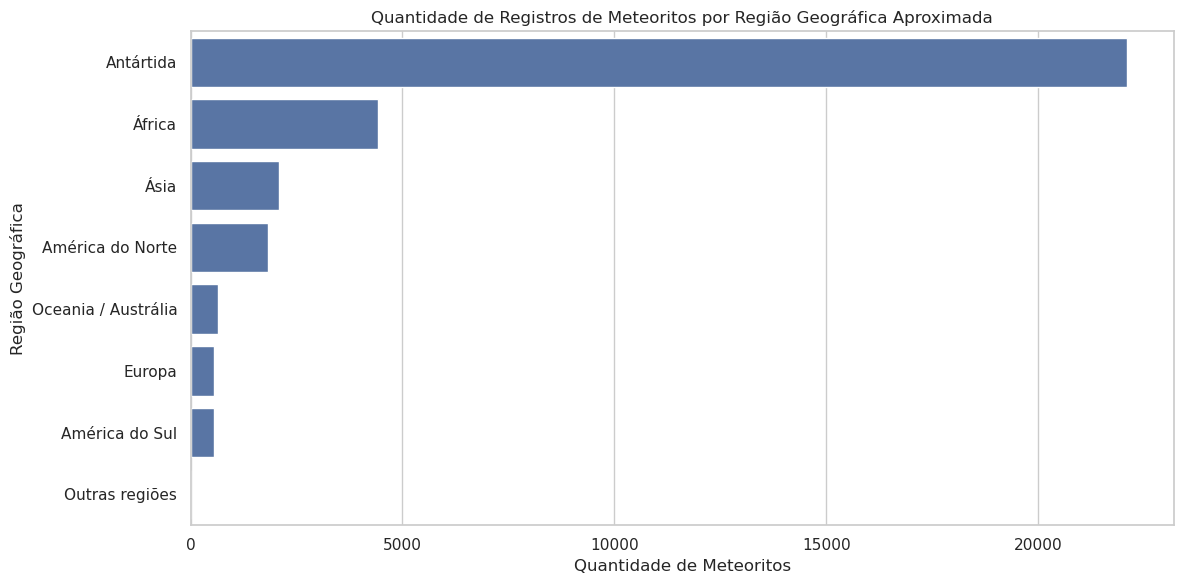

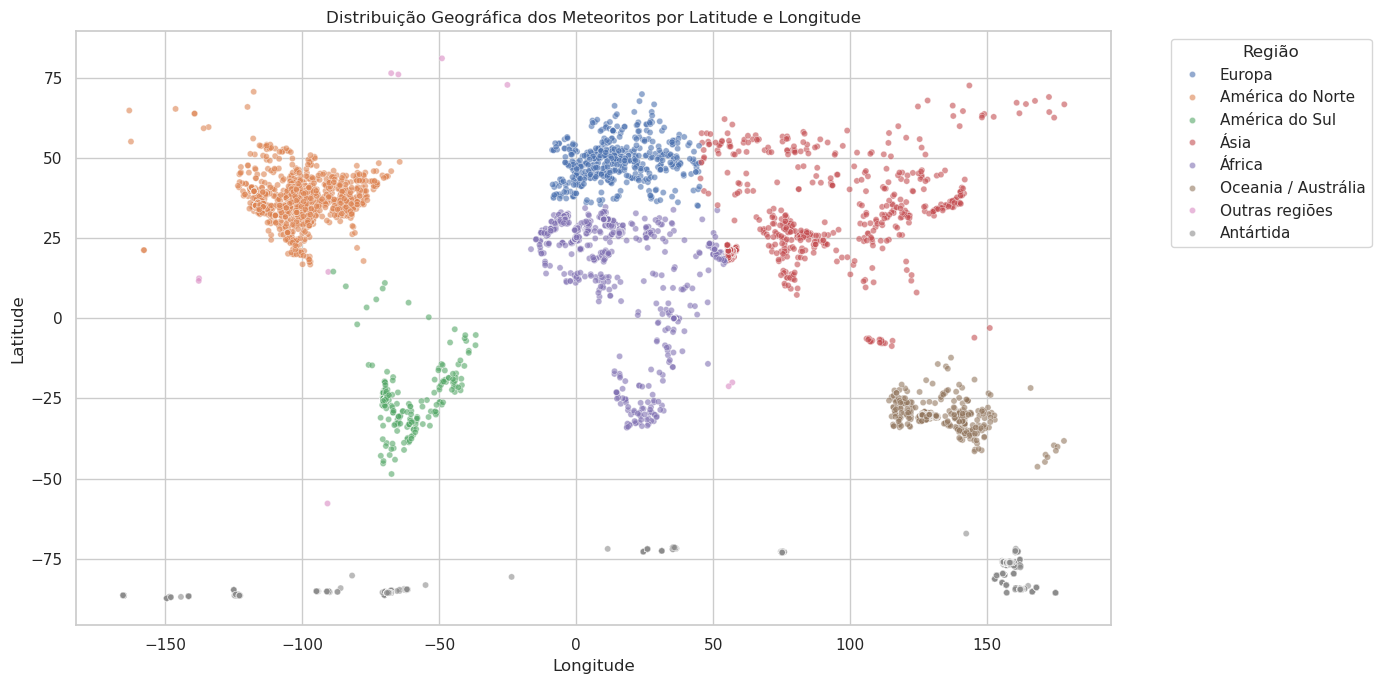

,name,recclass,fall,reclat,reclong,geolocation,regiao_geografica
0,Aachen,L5,Fell,50.77500,6.08333,"(50.775, 6.08333)",Europa
1,Aarhus,H6,Fell,56.18333,10.23333,"(56.18333, 10.23333)",Europa
2,Abee,EH4,Fell,54.21667,-113.00000,"(54.21667, -113.0)",América do Norte
3,Acapulco,Acapulcoite,Fell,16.88333,-99.90000,"(16.88333, -99.9)",América do Norte
4,Achiras,L6,Fell,-33.16667,-64.95000,"(-33.16667, -64.95)",América do Sul
5,Adhi Kot,EH4,Fell,32.10000,71.80000,"(32.1, 71.8)",Ásia
6,Adzhi-Bogdo (stone),LL3-6,Fell,44.83333,95.16667,"(44.83333, 95.16667)",Ásia
7,Agen,H5,Fell,44.21667,0.61667,"(44.21667, 0.61667)",Europa
8,Aguada,L6,Fell,-31.60000,-65.23333,"(-31.6, -65.23333)",América do Sul
9,Aguila Blanca,L,Fell,-30.86667,-64.55000,"(-30.86667, -64.55)",América do Sul


In [1]:
# Importa biblioteca principal para análise de dados
import pandas as pd

# Importa bibliotecas para criação de gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Importa biblioteca para exibir tabelas no Jupyter
from IPython.display import display

# Importa bibliotecas para limpar nomes das colunas
import re
import unicodedata

# Define o estilo visual dos gráficos
sns.set_theme(style="whitegrid")

# Faz o Pandas mostrar todas as colunas
pd.set_option("display.max_columns", None)

# Faz o Pandas mostrar até 100 linhas
pd.set_option("display.max_rows", 100)

# Link direto do dataset da NASA
url = "https://data.nasa.gov/docs/legacy/meteorite_landings/Meteorite_Landings.csv"

# Lê o dataset direto do link
df = pd.read_csv(url)

# Função para padronizar os nomes das colunas
def limpar_nome_coluna(nome):
    # Converte o nome da coluna para texto
    nome = str(nome)

    # Remove acentos, caso existam
    nome = unicodedata.normalize("NFKD", nome)
    nome = nome.encode("ascii", "ignore").decode("utf-8")

    # Converte para letras minúsculas
    nome = nome.lower()

    # Remove espaços no começo e no final
    nome = nome.strip()

    # Troca espaços e caracteres especiais por "_"
    nome = re.sub(r"[^a-z0-9]+", "_", nome)

    # Remove "_" do começo e do final
    nome = nome.strip("_")

    # Retorna o nome padronizado
    return nome

# Padroniza os nomes das colunas
df.columns = [limpar_nome_coluna(coluna) for coluna in df.columns]

# Converte latitude e longitude para valores numéricos
# Valores inválidos serão transformados em NaN
df["reclat"] = pd.to_numeric(df["reclat"], errors="coerce")
df["reclong"] = pd.to_numeric(df["reclong"], errors="coerce")

# Remove registros sem latitude ou longitude
df_geo = df.dropna(subset=["reclat", "reclong"]).copy()

# Mantém apenas coordenadas dentro dos limites reais do planeta
df_geo = df_geo[
    (df_geo["reclat"] >= -90) &
    (df_geo["reclat"] <= 90) &
    (df_geo["reclong"] >= -180) &
    (df_geo["reclong"] <= 180)
].copy()

# Remove registros com latitude 0 e longitude 0 ao mesmo tempo
# Em muitos datasets, coordenada (0, 0) pode representar localização ausente ou imprecisa
df_geo = df_geo[~((df_geo["reclat"] == 0) & (df_geo["reclong"] == 0))].copy()

# Função simples para classificar regiões aproximadas do mundo
def classificar_regiao(latitude, longitude):
    # Antártida
    if latitude <= -60:
        return "Antártida"

    # América do Norte
    elif -170 <= longitude <= -50 and 15 <= latitude <= 75:
        return "América do Norte"

    # América do Sul
    elif -90 <= longitude <= -30 and -60 <= latitude < 15:
        return "América do Sul"

    # Europa
    elif -25 <= longitude <= 45 and 35 <= latitude <= 75:
        return "Europa"

    # África
    elif -20 <= longitude <= 55 and -35 <= latitude < 35:
        return "África"

    # Ásia
    elif 45 < longitude <= 180 and -10 <= latitude <= 80:
        return "Ásia"

    # Oceania / Austrália
    elif 110 <= longitude <= 180 and -50 <= latitude < -10:
        return "Oceania / Austrália"

    # Outras áreas
    else:
        return "Outras regiões"

# Cria uma nova coluna com a região aproximada
df_geo["regiao_geografica"] = df_geo.apply(
    lambda linha: classificar_regiao(linha["reclat"], linha["reclong"]),
    axis=1
)

# Conta a quantidade de meteoritos por região
contagem_regioes = (
    df_geo["regiao_geografica"]
    .value_counts()
    .reset_index()
)

# Renomeia as colunas para ficar mais amigável
contagem_regioes.columns = ["regiao_geografica", "quantidade"]

# Mostra a tabela com as regiões de maior concentração
display(contagem_regioes)

# Cria um gráfico de barras com a quantidade por região
plt.figure(figsize=(12, 6))

sns.barplot(
    data=contagem_regioes,
    x="quantidade",
    y="regiao_geografica"
)

plt.title("Quantidade de Registros de Meteoritos por Região Geográfica Aproximada")
plt.xlabel("Quantidade de Meteoritos")
plt.ylabel("Região Geográfica")
plt.tight_layout()
plt.show()

# Cria um gráfico de dispersão usando longitude e latitude
plt.figure(figsize=(14, 7))

sns.scatterplot(
    data=df_geo,
    x="reclong",
    y="reclat",
    hue="regiao_geografica",
    alpha=0.6,
    s=20
)

plt.title("Distribuição Geográfica dos Meteoritos por Latitude e Longitude")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Região", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Mostra alguns exemplos dos registros usados na análise
display(
    df_geo[[
        "name",
        "recclass",
        "fall",
        "reclat",
        "reclong",
        "geolocation",
        "regiao_geografica"
    ]].head(20)
)